# SEIRS-SEI Malaria Model — Warm-Up / Spin-Up

**Problem**: The model's initial conditions (E_H0, R_H0, I_M0, etc.) are arbitrary estimates,
placing the system at the wrong phase of the epidemic cycle. The model therefore shows a
phase lag relative to observed data.

**Solution**: Run the model for several years *before* the data period using real climate data
(2012–2016). The system converges to its natural attractor/limit cycle. The final state of
the warm-up becomes the initial condition for the main simulation (2017–2023).

This eliminates dependence on arbitrary initial conditions.

In [2]:
import sys
sys.path.append("..")

from ode_models.seirs_sei_ode_shared import *

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos in 2012 was estimated to be ~4
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


## Load Extended Climate Data (2012–2024)

The shared module loads climate data only from 2016–2024. We additionally load
2012–2015 data and concatenate to cover the full warm-up + simulation period.

In [4]:
#### Load and concatenate climate data 2012-2024 (no gaps)

# Load both raw CSVs directly (shared module's climate_data is filtered to 2017-2023)
climate_2012_2015 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2012_2015.csv")
)
climate_2016_2024 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2016_2024.csv")
)

climate_2012_2015["date"] = pd.to_datetime(climate_2012_2015["date"])
climate_2016_2024["date"] = pd.to_datetime(climate_2016_2024["date"])

# Concatenate: 2012-01-01 to 2024-12-31 (contiguous)
climate_full = pd.concat([climate_2012_2015, climate_2016_2024], ignore_index=True)
climate_full = climate_full.reset_index(drop=True)

# Filter to our simulation period (2012-01-01 to 2023-12-31)
climate_full = climate_full[
    (climate_full['date'] >= '2012-01-01') & (climate_full['date'] <= '2023-12-31')
].reset_index(drop=True)

# Warm-up: 2012-01-01 to 2016-12-31 (indices 0 to 1826)
# Main:    2017-01-01 to 2023-12-31 (indices 1827 onwards)
warmup_end_idx = (climate_full['date'] < '2017-01-01').sum()  # number of days before 2017
num_warmup_days = warmup_end_idx
num_main_days = len(climate_full) - warmup_end_idx
num_total_days = len(climate_full)

print(f"Climate data 2012-2024 (combined): {num_total_days} days")
print(f"Warm-up period (2012-2016): {num_warmup_days} days")
print(f"Main period (2017-2023): {num_main_days} days")
print(f"Date range: {climate_full['date'].iloc[0].date()} to {climate_full['date'].iloc[-1].date()}")

Climate data 2012-2024 (combined): 4383 days
Warm-up period (2012-2016): 1827 days
Main period (2017-2023): 2556 days
Date range: 2012-01-01 to 2023-12-31


In [5]:
#### Add smoothed climate columns (same as shared module)
climate_full["temp_med_smooth"] = (
    climate_full["temp_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["precip_med_smooth"] = (
    climate_full["precip_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["umid_min_smooth"] = (
    climate_full["umid_min"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
print("Smoothed columns added to climate_full")

Smoothed columns added to climate_full


## Generic Initial Conditions (2012)

These do NOT need to be accurate — the warm-up will converge to the attractor.
We use small arbitrary values for all compartments except S_H and S_M.

In [7]:
pop_by_year

{2000: 9053.849372081258,
 2001: 9088.952949632278,
 2002: 9117.256294264524,
 2003: 9139.05723321406,
 2004: 9154.649411302698,
 2005: 9164.31617521152,
 2006: 9168.3253162671,
 2007: 9166.951842374643,
 2008: 9160.44439417914,
 2009: 9149.048270856498,
 2010: 9132.999999999847,
 2011: 9023.393025831943,
 2012: 8913.827041834475,
 2013: 8804.362254238276,
 2014: 8695.060580948119,
 2015: 8585.967235820563,
 2016: 8477.138774809348,
 2017: 8368.624449272125,
 2018: 8260.475194033448,
 2019: 8152.726901118595,
 2020: 8045.4258852655,
 2021: 7938.611948059947,
 2022: 7832.326537074163,
 2023: 7942.253688666368,
 2024: 8042.503503612287,
 2025: 8133.478083355584}

In [8]:
#### Generic initial conditions for 2012-01-01

print(f"N_warmup (2012 pop) = {N_2012}")
print(f"M_0_warmup = {warmup_M_0}")
print(f"Initial state: S_H={warmup_S_H0}, E_H={warmup_E_H0}, I_H={warmup_I_H0}, R_H={warmup_R_H0}")
print(f"              S_M={warmup_S_M0}, E_M={warmup_E_M0}, I_M={warmup_I_M0}")

N_warmup (2012 pop) = 8914
M_0_warmup = 89140
Initial state: S_H=5365, E_H=446, I_H=1766, R_H=1337
              S_M=85576, E_M=2673, I_M=891


## Run Full Simulation (2012–2023)

We run the ODE from 2012-01-01 to 2023-12-31 in one call using the concatenated
climate data. The first ~5 years (2012–2016) serve as warm-up. The system should
converge to its natural limit cycle during this period.

In [10]:
#### Run the ODE for the full period

M_prime_full = warmup_M_0

state_warmup = initial_state_2012.copy()

def ode_func_full(t, z):
    return seirs_sei_ode(
        t, z, N_2012, climate_full,
        T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
        c1, c2, D1, b1, b2, A, B, C, DD,
        Tmin, optimal_temp_plasm, critical_max_temp_plasm,
        optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
        gamma, R_L, M_prime_full, tau_H, omega,
        M_min=M_min, permanent_factor=permanent_factor,
        use_smooth_climate=USE_SMOOTH_CLIMATE,
    )

t_span = (0, num_total_days)
t_eval = np.arange(0, num_total_days, 1)  # daily output

print("Running ODE for 2012-01-01 to 2023-12-31...")
print(f"  t_span: 0 to {num_total_days} days")
print(f"  t_eval: {len(t_eval)} points")

sol_full = solve_ivp(
    ode_func_full,
    t_span,
    state_warmup,
    t_eval=t_eval,
    method='LSODA'
)

print(f"  Solver success: {sol_full.success}")

# Extract results
dates_full = climate_full['date'].values
S_H_full = sol_full.y[0]
E_H_full = sol_full.y[1]
I_H_full = sol_full.y[2]
R_H_full = sol_full.y[3]
S_M_full = sol_full.y[4]
E_M_full = sol_full.y[5]
I_M_full = sol_full.y[6]

Running ODE for 2012-01-01 to 2023-12-31...
  t_span: 0 to 4383 days
  t_eval: 4383 points
  Solver success: True


## Extract Main Period (2017–2023)

Discard the warm-up portion and keep only the simulation years that overlap
with observed malaria data.

In [12]:
#### Extract 2017-2023 for comparison with data

# Warm-up end state = initial condition for the data period
warmup_end_state = sol_full.y[:, warmup_end_idx]

# Main period data
dates_main = dates_full[warmup_end_idx:]
I_H_main = I_H_full[warmup_end_idx:]

print(f"Main period: {len(dates_main)} days (2017-01-01 to 2023-12-31)")
print(f"Warm-up end state (used as IC for 2017):")
print(f"  S_H={warmup_end_state[0]:.0f}, E_H={warmup_end_state[1]:.0f}, I_H={warmup_end_state[2]:.0f}, R_H={warmup_end_state[3]:.0f}")
print(f"  S_M={warmup_end_state[4]:.0f}, E_M={warmup_end_state[5]:.0f}, I_M={warmup_end_state[6]:.0f}")

Main period: 2556 days (2017-01-01 to 2023-12-31)
Warm-up end state (used as IC for 2017):
  S_H=8901, E_H=0, I_H=0, R_H=13
  S_M=63984, E_M=0, I_M=0


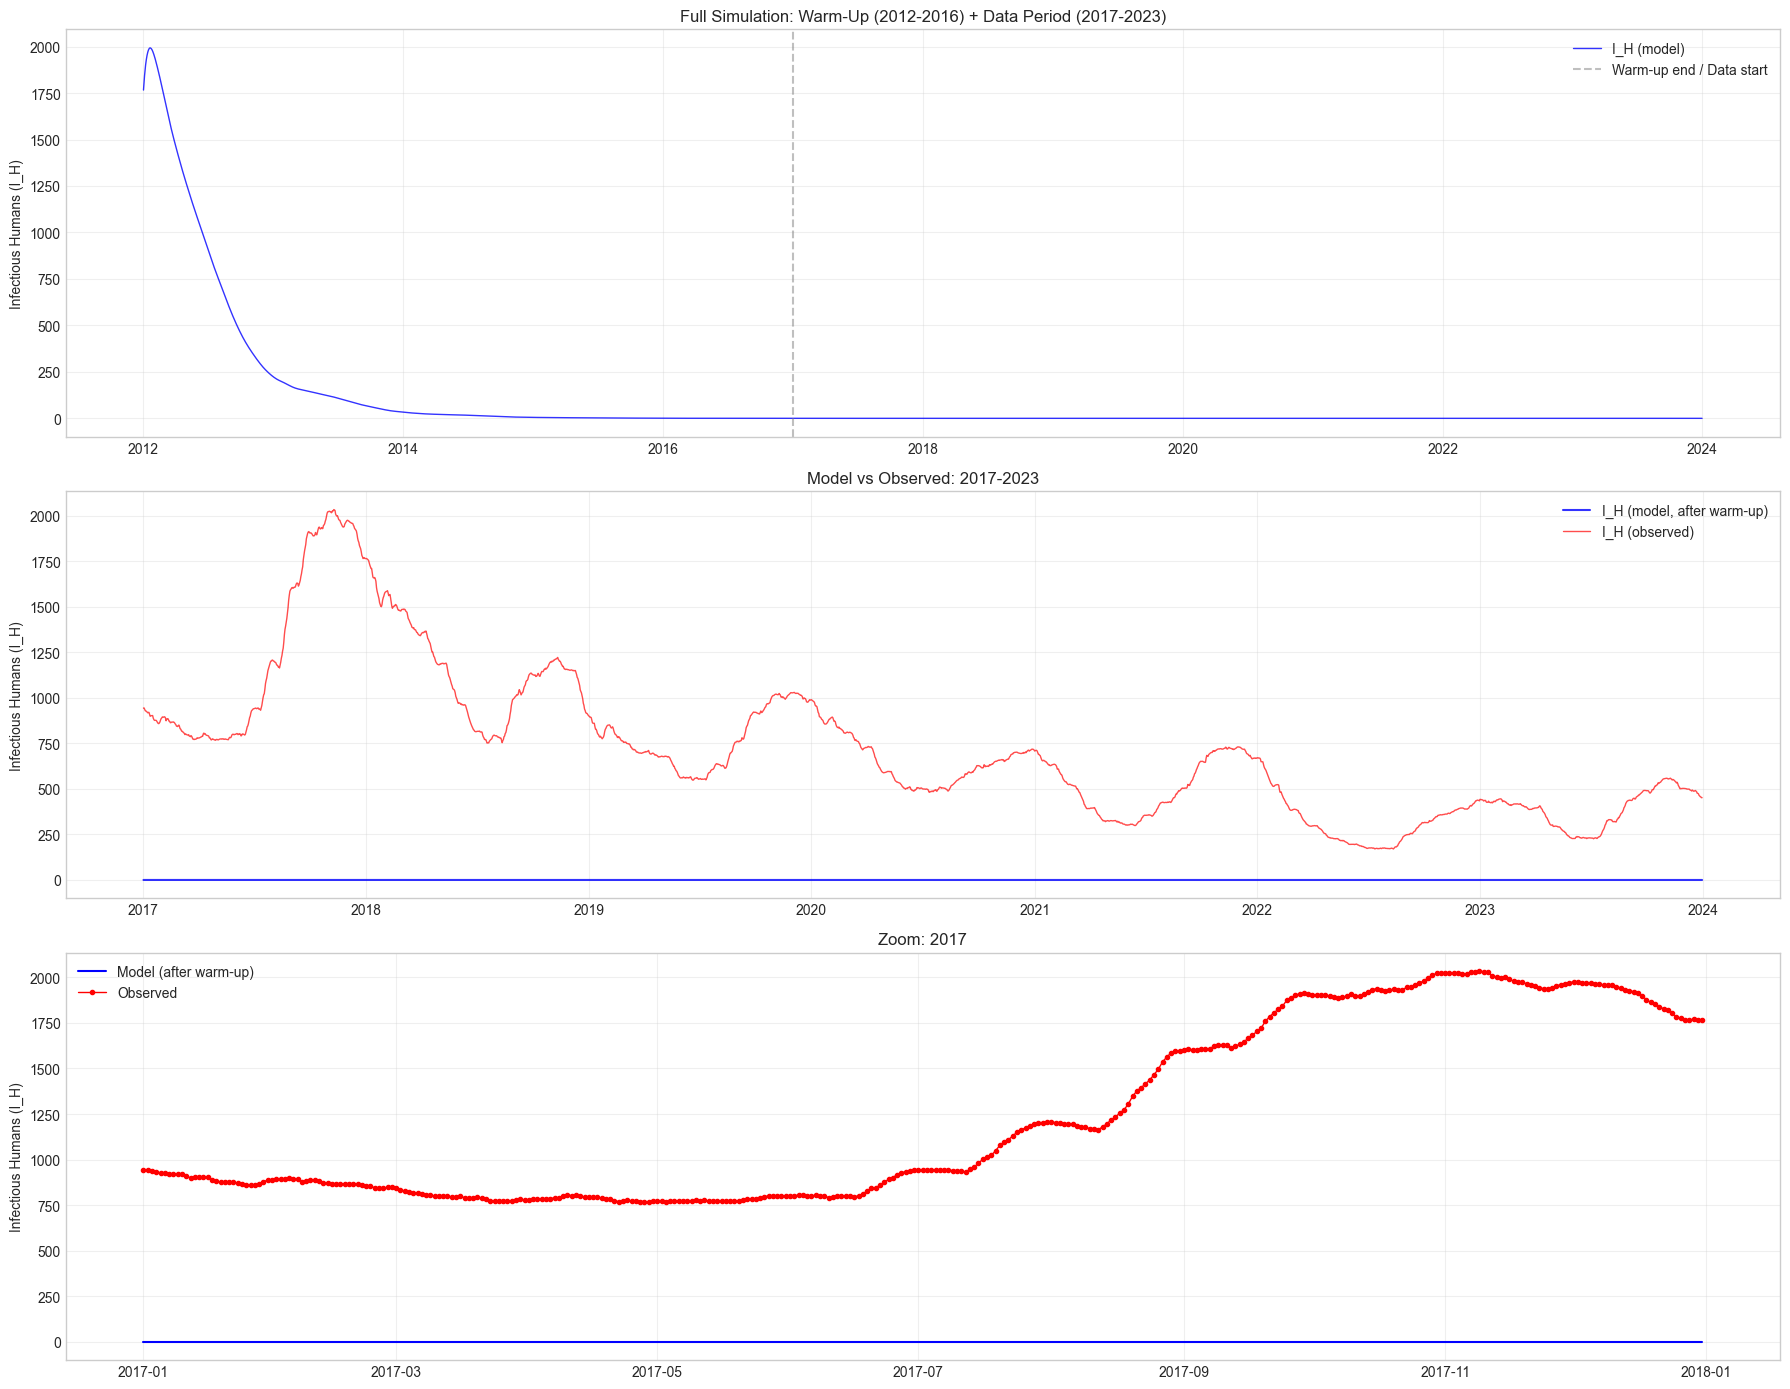

In [13]:
#### Plot results

fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# Top: Full period including warm-up
ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_full), I_H_full, 'b-', linewidth=1.0, alpha=0.8, label='I_H (model)')
ax1.axvline(pd.to_datetime('2017-01-01'), color='gray', linestyle='--', alpha=0.5, label='Warm-up end / Data start')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Full Simulation: Warm-Up (2012-2016) + Data Period (2017-2023)')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Middle: Main period vs observed
ax2 = axes[1]
ax2.plot(pd.to_datetime(dates_main), I_H_main, 'b-', linewidth=1.5, alpha=0.8, label='I_H (model, after warm-up)')
ax2.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='I_H (observed)')
ax2.set_ylabel('Infectious Humans (I_H)')
ax2.set_title('Model vs Observed: 2017-2023')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Bottom: Zoom to 2017 only (first year)
ax3 = axes[2]
mask_2017 = pd.to_datetime(dates_main).year == 2017
ax3.plot(pd.to_datetime(dates_main)[mask_2017], I_H_main[mask_2017], 'b-', linewidth=1.5, label='Model (after warm-up)')
mask_obs_2017 = rural_cases_df['date'].dt.year == 2017
ax3.plot(rural_cases_df['date'][mask_obs_2017], rural_cases_df['active_total'][mask_obs_2017],
         'ro-', markersize=3, linewidth=1.0, label='Observed')
ax3.set_ylabel('Infectious Humans (I_H)')
ax3.set_title('Zoom: 2017')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
#### Evaluate fit for the main period

# Interpolate model to observed dates for exact comparison
model_interp = interp1d(
    pd.to_datetime(dates_main).astype(np.int64),
    I_H_main,
    kind='linear',
    fill_value='extrapolate'
)
obs_dates_int = rural_cases_df['date'].astype(np.int64).values
model_at_obs = model_interp(obs_dates_int)
observed = rural_cases_df['active_total'].values

mse = np.mean((model_at_obs - observed) ** 2)
mae = np.mean(np.abs(model_at_obs - observed))
rmse = np.sqrt(mse)

print(f"Fit metrics (2017-2023):")
print(f"  MSE  = {mse:,.2f}")
print(f"  RMSE = {rmse:,.2f}")
print(f"  MAE  = {mae:,.2f}")
print(f"  Mean observed I_H = {np.mean(observed):,.1f}")
print(f"  RMSE / Mean = {rmse / np.mean(observed):.2%}")

Fit metrics (2017-2023):
  MSE  = 689,008.68
  RMSE = 830.07
  MAE  = 722.30
  Mean observed I_H = 722.3
  RMSE / Mean = 114.92%


In [15]:
#### Compare: warm-up ICs vs original default ICs

print("Comparison of initial conditions for 2017:")
print(f"{'':<30} {'Default ICs':>15} {'Warm-up ICs':>15}")
print(f"{'':<30} {'-----------':>15} {'------------':>15}")
print(f"{'S_H0':<30} {initial_state_2017[0]:>15.0f} {warmup_end_state[0]:>15.0f}")
print(f"{'E_H0':<30} {initial_state_2017[1]:>15.0f} {warmup_end_state[1]:>15.0f}")
print(f"{'I_H0 (from data)':<30} {initial_state_2017[2]:>15.0f} {warmup_end_state[2]:>15.0f}")
print(f"{'R_H0':<30} {initial_state_2017[3]:>15.0f} {warmup_end_state[3]:>15.0f}")
print(f"{'S_M0':<30} {initial_state_2017[4]:>15.0f} {warmup_end_state[4]:>15.0f}")
print(f"{'E_M0':<30} {initial_state_2017[5]:>15.0f} {warmup_end_state[5]:>15.0f}")
print(f"{'I_M0':<30} {initial_state_2017[6]:>15.0f} {warmup_end_state[6]:>15.0f}")

Comparison of initial conditions for 2017:
                                   Default ICs     Warm-up ICs
                                   -----------    ------------
S_H0                                      5752            8901
E_H0                                       418               0
I_H0 (from data)                           944               0
R_H0                                      1255              13
S_M0                                     80342           63984
E_M0                                      2511               0
I_M0                                       837               0


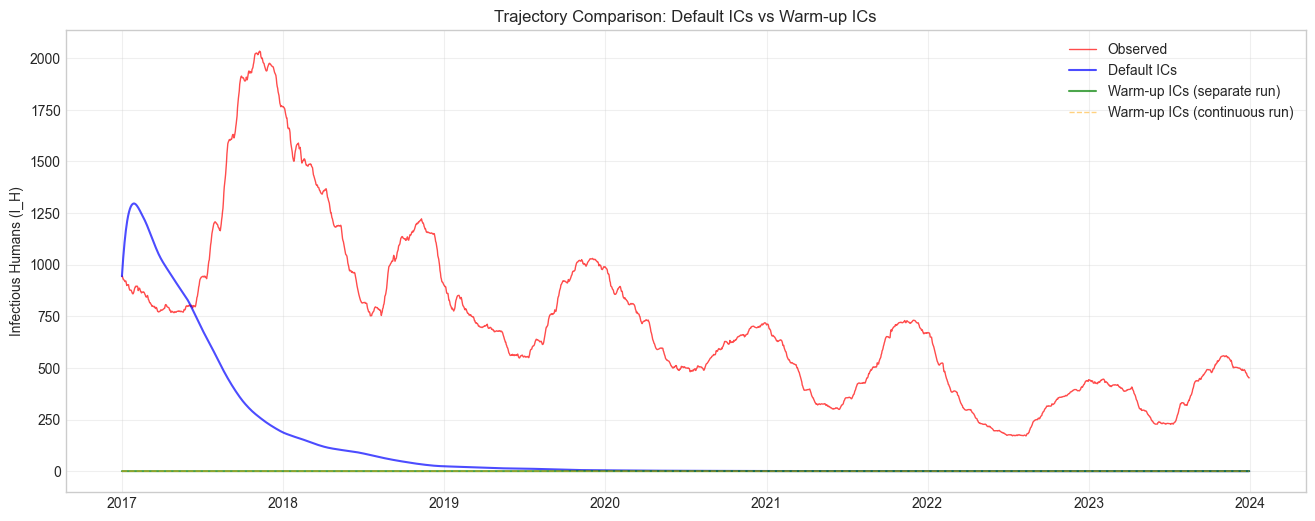

MSE comparison:
  Default ICs:    541,436.31
  Warm-up ICs:    689,006.99


In [16]:
#### Compare trajectories: default ICs vs warm-up ICs

# Run simulation with default ICs for 2017-2023
M_prime_default = M_0

def ode_func_default(t, z):
    return seirs_sei_ode(
        t, z, N_2017, climate_data,
        T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
        c1, c2, D1, b1, b2, A, B, C, DD,
        Tmin, optimal_temp_plasm, critical_max_temp_plasm,
        optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
        gamma, R_L, M_prime_default, tau_H, omega,
        M_min=M_min, permanent_factor=permanent_factor,
        use_smooth_climate=USE_SMOOTH_CLIMATE,
    )

t_eval_default = np.arange(0, len(climate_data), 1)
sol_default = solve_ivp(
    ode_func_default,
    (0, len(climate_data)),
    initial_state_2017,
    t_eval=t_eval_default,
    method='LSODA'
)
IH_default = sol_default.y[2] if sol_default.success else np.full(len(climate_data), np.nan)

# Also run with warm-up ICs for 2017-2023
M_prime_main = warmup_M_0

def ode_func_main(t, z):
    return seirs_sei_ode(
        t, z, N_2017, climate_data,
        T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
        c1, c2, D1, b1, b2, A, B, C, DD,
        Tmin, optimal_temp_plasm, critical_max_temp_plasm,
        optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
        gamma, R_L, M_prime_main, tau_H, omega,
        M_min=M_min, permanent_factor=permanent_factor,
        use_smooth_climate=USE_SMOOTH_CLIMATE,
    )

sol_main = solve_ivp(
    ode_func_main,
    (0, len(climate_data)),
    warmup_end_state,
    t_eval=t_eval_default,
    method='LSODA'
)
IH_main_separate = sol_main.y[2] if sol_main.success else np.full(len(climate_data), np.nan)

# Plot comparison
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax.plot(rural_cases_df['date'], IH_default, 'b-', linewidth=1.5, alpha=0.7, label='Default ICs')
ax.plot(rural_cases_df['date'], IH_main_separate, 'g-', linewidth=1.5, alpha=0.7, label='Warm-up ICs (separate run)')
ax.plot(pd.to_datetime(dates_main), I_H_main, 'orange', linewidth=1.0, alpha=0.5, linestyle='--', label='Warm-up ICs (continuous run)')
ax.set_ylabel('Infectious Humans (I_H)')
ax.set_title('Trajectory Comparison: Default ICs vs Warm-up ICs')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# Metrics
def compute_mse(model_ih):
    interp = interp1d(rural_cases_df['date'].astype(np.int64), model_ih, kind='linear', fill_value='extrapolate')
    return np.mean((interp(obs_dates_int) - observed) ** 2)

print(f"MSE comparison:")
print(f"  Default ICs:  {compute_mse(IH_default):>12,.2f}")
print(f"  Warm-up ICs:  {compute_mse(IH_main_separate):>12,.2f}")

## Next Steps

- If the warm-up reduces MSE, replace `initial_state_2017` with `warmup_end_state` in all calibration notebooks
- If still needed, calibrate gamma and tau_H on top of warm-up ICs
- The warm-up period can be extended if 5 years is insufficient for convergence